In [217]:
#main.py

def main():
    print("TEST")
    
if __name__ == "__main__":
    main()

TEST


In [253]:
from dataclasses import dataclass, field
from collections import deque

@dataclass
class Airport:
    code: str
    name: str
    
@dataclass
class Aircraft:
    tail_number: str
    base: str
    reserve: bool = False

    current_airport: str = ""
    available_time: int = 0
    assigned_flights: list[Flight] = field(default_factory=list)
    remaining_flights: deque[Flight] = field(default_factory=deque)

    def __post_init__(self):
        self.current_airport = self.base
        self.available_time = 0
        
    def reset(self, config):
        self.current_airport = self.base
        self.available_time = config.operating_day_start

        self.remaining_flights = deque(self.assigned_flights)

@dataclass
class Flight:
    flight_id: str

    aircraft_id: str | None

    origin: str
    destination: str

    scheduled_departure: int
    scheduled_arrival: int

    actual_departure: int = 0
    actual_arrival: int = 0

    delay_minutes: int = 0
    status: str = "Scheduled"
    
    def __post_init__(self):
        self.actual_departure = self.scheduled_departure
        self.actual_arrival = self.scheduled_arrival
    
    def reset(self):
        self.actual_departure = self.scheduled_departure
        self.actual_arrival = self.scheduled_arrival
        self.delay_minutes = 0
        self.status = "Scheduled"

@dataclass
class Route:
    origin: str
    destination: str
    flight_time: int
    flights_per_day: int
    remaining_flights: int = 0
    
    def reset(self):
        self.remaining_flights = self.flights_per_day


    
@dataclass(order=True)
class Event:
    time: int
    event_type: str      # Departure / Arrival #TODO define enum to rpevent typos
    flight: Flight = field(compare=False)
    

@dataclass
class Config:
    # Operations
    operating_day_start: int = 360
    operating_day_end: int = 1320
    turn_time: int = 45

    # Delay probabilities
    weather_delay_probability: float = 0.05
    gate_delay_probability: float = 0.08
    maintenance_probability: float = 0.01
    cancellation_probability: float = 0.005

    # Delay ranges
    weather_delay_min: int = 15
    weather_delay_max: int = 60

    gate_delay_min: int = 5
    gate_delay_max: int = 25

    maintenance_delay_min: int = 30
    maintenance_delay_max: int = 120

    random_seed: int = 42
    
@dataclass
class SimulationMetrics:
    total_flights: int = 0
    completed: int = 0
    cancelled: int = 0

    total_delay_minutes: int = 0
    max_delay: int = 0

    weather_delay_minutes: int = 0
    gate_delay_minutes: int = 0
    maintenance_delay_minutes: int = 0
    propagated_delay_minutes: int = 0

    def add_delay(self, delay_type, minutes):
        self.total_delay_minutes += minutes

        if delay_type == "weather":
            self.weather_delay_minutes += minutes

        elif delay_type == "gate":
            self.gate_delay_minutes += minutes

        elif delay_type == "maintenance":
            self.maintenance_delay_minutes += minutes

        elif delay_type == "propagated":
            self.propagated_delay_minutes += minutes


    def summary(self):
        average_delay = (
            self.total_delay_minutes / self.total_flights
            if self.total_flights
            else 0
        )

        return {
            "total_flights": self.total_flights,
            "completed": self.completed,
            "cancelled": self.cancelled,
            "total_delay_minutes": self.total_delay_minutes,
            "average_delay": round(average_delay, 2),
            "max_delay": self.max_delay,

            "weather_delay": self.weather_delay_minutes,
            "gate_delay": self.gate_delay_minutes,
            "maintenance_delay": self.maintenance_delay_minutes,
            "propagated_delay": self.propagated_delay_minutes,
        }
    def reset(self):
        self.total_flights = 0
        self.completed = 0
        self.cancelled = 0
    
        self.total_delay_minutes = 0
        self.max_delay = 0
    
        self.weather_delay_minutes = 0
        self.gate_delay_minutes = 0
        self.maintenance_delay_minutes = 0
        self.propagated_delay_minutes = 0
        

In [254]:
def build_event_queue(fleet):

    events = []

    for plane in fleet.values():

        if not plane.remaining_flights:
            continue

        first_flight = plane.remaining_flights[0]

        heapq.heappush(events, Event(time=first_flight.scheduled_departure, event_type="Departure", flight=first_flight))

    return events

In [255]:
#Build Schedule
def generate_schedule(fleet, routes, config):
    # Reset aircraft state
    for plane in fleet.values():
        plane.reset(config)

    # Reset route demand
    for route in routes.values():
        route.reset()
        
    schedule = []
    flight_number = 1
    for plane in fleet.values():

        while plane.available_time < config.operating_day_end:

            candidates = get_candidate_routes(plane.current_airport, routes)

            route = choose_best_route(candidates)

            if route is None or (plane.available_time + route.flight_time) > config.operating_day_end:
                break
            
            flight = create_flight(plane, route, flight_number)
            flight_number += 1
            
            update_aircraft(plane, route, flight, config)

            schedule.append(flight)
            
    return schedule


def get_candidate_routes(current_airport, routes):
    candidates = []

    for route in routes.values():
        if (route.origin == current_airport and route.remaining_flights > 0):
            candidates.append(route)

    return candidates

def choose_best_route(candidates):
    if not candidates:
        return None
    
    #Sort by Most Remaining flights > Shortest Flight Time > Alphabetical Destination
    best = sorted(candidates, key=lambda r: (-r.remaining_flights, r.flight_time, r.destination))
    # TODO: Eventually add a demand or something as a sorting method
    return best[0]

def create_flight(plane, route, flight_number):

    departure_time = plane.available_time
    arrival_time = departure_time + route.flight_time
    #TODO: eventually add an assertion to ensure this is all good
    return Flight(
        flight_id=f"DL{flight_number:04}",
        aircraft_id=plane.tail_number,

        origin=route.origin,
        destination=route.destination,

        scheduled_departure=departure_time,
        scheduled_arrival=arrival_time,
    )

def update_aircraft(plane, route, flight, config):
    plane.current_airport = flight.destination
    plane.available_time = (flight.scheduled_arrival + config.turn_time)
    plane.assigned_flights.append(flight)
    route.remaining_flights -= 1

    


In [256]:
def load_routes(filename):
    routes = {}

    with open(filename, "r") as f:
        json_data = json.load(f)

    for route in json_data:
        forward = Route(
            origin=route["origin"],
            destination=route["destination"],
            flight_time=route["flight_time"],
            flights_per_day=route["flights_per_day"],
        )
        
        routes[(forward.origin, forward.destination)] = forward
        
        if route.get("bidirectional", False):
            reverse = Route(
                origin=route["destination"],
                destination=route["origin"],
                flight_time=route["flight_time"],
                flights_per_day=route["flights_per_day"],
            )

            routes[(reverse.origin, reverse.destination)] = reverse
    return routes


def load_airports(filename):
    airports = {}

    with open(filename, "r") as f:
        json_data = json.load(f)
        
    for airport in json_data:
        location = Airport(
            code=airport["code"],
            name=airport["name"]
        )
        
        airports[location.code] = location
    
    return airports

def load_aircraft(filename):
    aircrafts = {}
    
    with open(filename, "r") as f:
        json_data = json.load(f)
        
    for aircraft in json_data:
        plane = Aircraft(
            tail_number=aircraft["tail_number"],
            base=aircraft["base"],
            reserve=aircraft.get("reserve", False)
        )
        
        aircrafts[plane.tail_number] = plane

    return aircrafts


In [257]:
import heapq
import random
        
def run_simulation(schedule, fleet, routes, config, simulation_seed):
    random.seed(simulation_seed)
    reset_simulation(schedule, fleet, routes, config)

    metrics = SimulationMetrics()
    metrics.total_flights = len(schedule)
    
    events = build_event_queue(fleet)

    while events:
        event = heapq.heappop(events)
        process_event(event, fleet, events, config, metrics)
        
    return metrics

In [258]:
#print(schedule)

def format_time(minutes):
    hours = minutes // 60
    mins = minutes % 60
    return f"{hours:02}:{mins:02}"

def print_schedule(schedule):
    print("=" * 80)
    print(f"{'Flight':<8} {'Aircraft':<8} {'Route':<15} {'Departure':<10} {'Arrival':<10}")
    print("=" * 80)

    for flight in schedule:
        route = f"{flight.origin} → {flight.destination}"

        print(
            f"{flight.flight_id:<8} "
            f"{flight.aircraft_id:<8} "
            f"{route:<15} "
            f"{format_time(flight.scheduled_departure):<10} "
            f"{format_time(flight.scheduled_arrival):<10}"
        )

    print("=" * 80)
    print(f"Total Flights Scheduled: {len(schedule)}")
    


In [259]:
total = 0

for route in ROUTES.values():
    total += route.flights_per_day

print(total)

92


In [260]:
def process_event(event, fleet, events, config, metrics):

    if event.event_type == "Departure":
        process_departure(event, fleet, events, config, metrics)

    elif event.event_type == "Arrival":
        process_arrival(event, fleet, events, config, metrics)

In [261]:
def process_departure(event, fleet, events, config, metrics):

    flight = event.flight

    # Cancellation check
    if random.random() < config.cancellation_probability:

        flight.status = "Cancelled"
        metrics.cancelled += 1

        #print(f"{flight.flight_id} CANCELLED "{flight.origin} → {flight.destination}")

        return


    # Track random delays
    total_delay = 0

    # Weather
    if random.random() < config.weather_delay_probability:
        delay = random.randint(15, 60)

        flight.actual_departure += delay
        flight.actual_arrival += delay

        flight.delay_minutes += delay
        metrics.add_delay("weather", delay)

        total_delay += delay


    # Gate
    if random.random() < config.gate_delay_probability:
        delay = random.randint(5, 25)

        flight.actual_departure += delay
        flight.actual_arrival += delay

        flight.delay_minutes += delay
        metrics.add_delay("gate", delay)

        total_delay += delay


    flight.status = "Departed"

    # Add arrival event using actual arrival time
    heapq.heappush(
        events,
        Event(
            time=flight.actual_arrival,
            event_type="Arrival",
            flight=flight
        )
    )


    #print(f"{flight.flight_id} departed {flight.origin} at {format_time(flight.actual_departure)}")

In [262]:
def process_arrival(event, fleet, events, config, metrics):

    flight = event.flight
    plane = fleet[flight.aircraft_id]


    # Update aircraft
    plane.current_airport = flight.destination

    plane.available_time = (
        flight.actual_arrival + config.turn_time
    )

    flight.status = "Arrived"
    
    metrics.max_delay = max(metrics.max_delay, flight.delay_minutes)

    metrics.completed += 1

    #print(f"{flight.flight_id} arrived {flight.destination} at {format_time(flight.actual_arrival)}")

    # Remove completed flight
    plane.remaining_flights.popleft()


    # No more flights for this aircraft
    if not plane.remaining_flights:
        return


    next_flight = plane.remaining_flights[0]


    # Propagate aircraft delay
    propagation_delay = max(
        0,
        plane.available_time - next_flight.scheduled_departure
    )


    if propagation_delay > 0:

        next_flight.delay_minutes += propagation_delay

        next_flight.actual_departure = (
            next_flight.scheduled_departure + propagation_delay
        )

        next_flight.actual_arrival = (
            next_flight.scheduled_arrival + propagation_delay
        )

        metrics.add_delay(
            "propagated",
            propagation_delay
        )

    else:

        next_flight.actual_departure = (
            next_flight.scheduled_departure
        )

        next_flight.actual_arrival = (
            next_flight.scheduled_arrival
        )

    # Cancel if pushed outside operating window
    if next_flight.actual_departure > config.operating_day_end:

        next_flight.status = "Cancelled"

        metrics.cancelled += 1

        plane.remaining_flights.popleft()

        return

    heapq.heappush(events, Event(time=next_flight.actual_departure, event_type="Departure", flight=next_flight))

In [263]:
import json

config = Config() #TODO add a config json and load_config
AIRPORTS = load_airports("data/airports.json")
AIRCRAFT = load_aircraft("data/aircraft.json")
ROUTES = load_routes("data/routes.json")

master_rng = random.Random(config.random_seed)

simulation_seeds = [master_rng.randint(0, 2**32 - 1)  for _ in range(1000)]
    
schedule = generate_schedule(AIRCRAFT, ROUTES, config)

print("\nRemaining Flights")
print("-" * 40)

for route in ROUTES.values():
    if route.remaining_flights > 0:
        print(
            f"{route.origin} -> {route.destination}: "
            f"{route.remaining_flights}"
        )
        
for plane in AIRCRAFT.values():
    print(
        plane.tail_number,
        "base:", plane.base,
        "current:", plane.current_airport,
        "time:", plane.available_time
    )
    

#print_schedule(schedule)


Remaining Flights
----------------------------------------
STL -> ATL: 1
MSP -> JFK: 1
BOS -> CLT: 1
CLT -> BOS: 1
STL -> CLT: 1
STL -> MCO: 1
MCO -> JFK: 1
BNA -> STL: 1
A001 base: ATL current: JFK time: 1280
A002 base: ATL current: STL time: 1250
A003 base: ATL current: MSP time: 1245
A004 base: ATL current: STL time: 1250
A005 base: ATL current: ATL time: 1365
A006 base: DTW current: ATL time: 1220
A007 base: DTW current: DTW time: 1345
A008 base: JFK current: BNA time: 1285
A009 base: JFK current: ATL time: 1280
A010 base: MSP current: MCO time: 1240
A011 base: MSP current: MSP time: 1315
A012 base: CLT current: ATL time: 1240
A013 base: MCO current: DTW time: 650
A014 base: JFK current: MSP time: 1305
A015 base: ATL current: ATL time: 360


In [270]:
#metrics = run_simulation(schedule, AIRCRAFT, config)


results = []

for seed in simulation_seeds:
    metrics = run_simulation(schedule, AIRCRAFT, ROUTES, config, seed)
    results.append(metrics)
    
    
print(len(results))

1000


In [265]:
def reset_fleet(fleet):

    for plane in fleet.values():
        plane.current_airport = plane.base
        plane.available_time = 360
        plane.remaining_flights = deque(plane.assigned_flights)
                                        
def reset_simulation(schedule, fleet, routes, config):

    for flight in schedule:
        flight.reset()

    for plane in fleet.values():
        plane.reset(config)

    for route in routes.values():
        route.reset()
                                       

In [266]:
assert (
    metrics.total_delay_minutes ==
    metrics.weather_delay_minutes +
    metrics.gate_delay_minutes +
    metrics.maintenance_delay_minutes +
    metrics.propagated_delay_minutes
)

In [267]:
results = []

for flight in schedule:
    results.append({
        "flight_id": flight.flight_id,
        "aircraft": flight.aircraft_id,
        "route": f"{flight.origin}-{flight.destination}",
        "scheduled_departure": flight.scheduled_departure,
        "actual_departure": flight.actual_departure,
        "delay": flight.delay_minutes,
        "status": flight.status
    })

In [271]:
import pandas as pd

flight_df = pd.DataFrame(results)

print(flight_df)

     total_flights  completed  cancelled  total_delay_minutes  max_delay  \
0               84         84          0                  961         84   
1               84         84          0                  793         63   
2               84         84          0                  900         64   
3               84         84          0                 1281         69   
4               84         79          2                 1581         89   
..             ...        ...        ...                  ...        ...   
995             84         84          0                  409         46   
996             84         84          0                  797         67   
997             84         81          1                  925         94   
998             84         84          0                 1830         90   
999             84         84          0                  569         46   

     weather_delay_minutes  gate_delay_minutes  maintenance_delay_minutes  \
0         

(array([ 7.,  3.,  6.,  5., 20., 19., 29., 34., 35., 45., 42., 35., 75.,
        54., 38., 54., 58., 43., 60., 48., 40., 27., 29., 33., 25., 24.,
        23., 11., 17.,  9., 11.,  5.,  8.,  5.,  4.,  6.,  3.,  3.,  2.,
         1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.]),
 array([ 138.  ,  186.16,  234.32,  282.48,  330.64,  378.8 ,  426.96,
         475.12,  523.28,  571.44,  619.6 ,  667.76,  715.92,  764.08,
         812.24,  860.4 ,  908.56,  956.72, 1004.88, 1053.04, 1101.2 ,
        1149.36, 1197.52, 1245.68, 1293.84, 1342.  , 1390.16, 1438.32,
        1486.48, 1534.64, 1582.8 , 1630.96, 1679.12, 1727.28, 1775.44,
        1823.6 , 1871.76, 1919.92, 1968.08, 2016.24, 2064.4 , 2112.56,
        2160.72, 2208.88, 2257.04, 2305.2 , 2353.36, 2401.52, 2449.68,
        2497.84, 2546.  ]),
 <BarContainer object of 50 artists>)

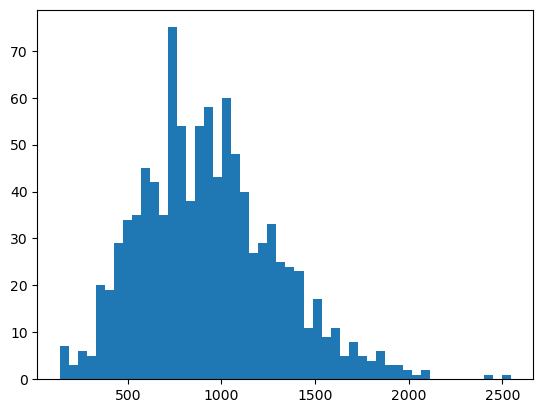

In [276]:
flight_df.describe()
flight_df["total_delay_minutes"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
plt.hist(flight_df["total_delay_minutes"], bins=50)

In [274]:
import matplotlib.pyplot as plt